In [1]:
import pathlib
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = next(
    (
        parent
        for parent in (
            pathlib.Path.cwd(),
            *pathlib.Path.cwd().parents,
        )
        if (parent / "benchmark/examples/diffusion/config.py").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Launch this notebook from inside the benchmark2 repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import BASE_DIR, MODELS

RESULTS_DIR = BASE_DIR / "results" / "direct"

DIRECT_NETWORK_DIR = BASE_DIR / "approximators" / "trained" / "direct"

INDIRECT_TAG = "S4D"

EXPECTED_LOSSES = (
    "cent",
    "exponential",
    "logistic",
)

LOSS_KEYS = {"cent": "cross_entropy", "exponential": "exponential", "logistic": "logistic"}

LOSS_LABELS = {
    "cent": "Cross-entropy",
    "exponential": "Exponential",
    "logistic": "Logistic",
}

LOSS_FUNCTIONS = tuple(
    loss
    for loss in EXPECTED_LOSSES
    if (DIRECT_NETWORK_DIR / f"direct_{loss}.keras").is_file()
)

MISSING_LOSSES = tuple(loss for loss in EXPECTED_LOSSES if loss not in LOSS_FUNCTIONS)

print("Direct network directory:", DIRECT_NETWORK_DIR)
print(
    "Available direct checkpoints:",
    ", ".join(LOSS_FUNCTIONS) or "none",
)
print(
    "Missing direct checkpoints:",
    ", ".join(MISSING_LOSSES) or "none",
)

if not LOSS_FUNCTIONS:
    raise FileNotFoundError(f"No direct checkpoints found in {DIRECT_NETWORK_DIR}")

FIGURE_DIR = RESULTS_DIR / "direct_loss_comparison" / "figures"

DATASETS_TO_PLOT = None
FIGURE_SUFFIX = "all"

def file_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def add_recovery_facet_strips(fig, axes, column_labels, row_labels):
    """Match the Gaussian direct/indirect PMP comparison layout."""
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_height = 0.55 / fig.get_figheight()
    right_width = 0.058

    for ax, label in zip(axes[0], column_labels, strict=True):
        pos = ax.get_position()
        strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_height])
        strip.set_facecolor(strip_color)
        strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=21)
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)

    for ax, label in zip(axes[:, -1], row_labels, strict=True):
        pos = ax.get_position()
        strip = fig.add_axes([pos.x1 + pad, pos.y0, right_width, pos.height])
        strip.set_facecolor(strip_color)
        strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center",
                   fontsize=19)
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)


Direct network directory: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/direct
Available direct checkpoints: cent, exponential, logistic
Missing direct checkpoints: none


In [2]:
comparison_by_loss = {}
indirect_configurations = set()
probability_columns = [
    f"p_{method}_{model}"
    for method in ("gold", "indirect", "direct")
    for model in MODELS
]
for loss in LOSS_FUNCTIONS:
    path = RESULTS_DIR / f"direct_{LOSS_KEYS[loss]}" / "pmp_comparison.csv"
    frame = pd.read_csv(path, dtype={"dataset": str, "id": str})
    if frame[["dataset", "id"]].isna().any().any():
        raise ValueError(f"Missing dataset keys in {path}")
    frame = frame.set_index(["dataset", "id"]).sort_index()
    if not frame.index.is_unique:
        raise ValueError(f"Duplicate dataset keys in {path}")
    probabilities = frame[probability_columns].to_numpy(dtype=float)
    if (
        not np.isfinite(probabilities).all()
        or not ((probabilities >= -1e-7) & (probabilities <= 1 + 1e-7)).all()
    ):
        raise ValueError(f"Invalid or missing PMP values in {path}")
    if not np.allclose(
        probabilities.reshape(-1, 3, len(MODELS)).sum(axis=2), 1, atol=1e-6
    ):
        raise ValueError(f"PMP components do not sum to one in {path}")
    if (
        "indirect_configuration" not in frame
        or frame["indirect_configuration"].isna().any()
    ):
        raise ValueError(f"Missing indirect configuration provenance in {path}")
    indirect_configurations.update(frame["indirect_configuration"].unique())
    comparison_by_loss[loss] = frame

if len(indirect_configurations) != 1:
    raise ValueError(
        f"Expected one shared indirect baseline: {indirect_configurations}"
    )
INDIRECT_LABEL = next(iter(indirect_configurations))
reference_frame = comparison_by_loss[LOSS_FUNCTIONS[0]]
reference_index = reference_frame.index
if reference_index.empty:
    raise ValueError("The PMP comparison files contain no datasets.")
shared_columns = [
    f"p_{method}_{model}" for method in ("gold", "indirect") for model in MODELS
]
for loss, frame in comparison_by_loss.items():
    if not frame.index.equals(reference_index):
        missing = reference_index.difference(frame.index)
        extra = frame.index.difference(reference_index)
        raise ValueError(
            f"Dataset mismatch for {loss}: {len(missing)} missing, {len(extra)} extra."
        )
    if not np.allclose(
        frame[shared_columns], reference_frame[shared_columns], rtol=0, atol=1e-12
    ):
        raise ValueError(f"Gold or indirect PMP differs across losses for {loss}")

available_datasets = tuple(reference_index.get_level_values("dataset").unique())
selected_datasets = (
    available_datasets if DATASETS_TO_PLOT is None else tuple(DATASETS_TO_PLOT)
)
if not selected_datasets or len(set(selected_datasets)) != len(selected_datasets):
    raise ValueError("DATASETS_TO_PLOT must contain distinct observed source names.")
missing_datasets = set(selected_datasets) - set(available_datasets)
if missing_datasets:
    raise ValueError(
        f"Observed sources missing from the comparison files: {sorted(missing_datasets)}"
    )
selected_index = reference_index[
    reference_index.get_level_values("dataset").isin(selected_datasets)
]
plot_data_by_loss = {
    loss: comparison_by_loss[loss].loc[selected_index].copy() for loss in LOSS_FUNCTIONS
}
figure_suffix = FIGURE_SUFFIX
for loss in LOSS_FUNCTIONS:
    print(f"Loaded {len(comparison_by_loss[loss])} datasets for {loss}.")
print(f"Indirect baseline: {INDIRECT_LABEL}")
print(
    f"Plotting {len(selected_index)} datasets per loss from: {', '.join(selected_datasets)}"
)
pd.concat(plot_data_by_loss, names=["loss_function"]).head()

Loaded 136 datasets for cent.
Loaded 136 datasets for exponential.
Loaded 136 datasets for logistic.
Indirect baseline: S4D
Plotting 136 datasets per loss from: empirical, m3_fast_30, m3_fast_slow_30, m3_slow_30, simulated_from_m0, simulated_from_m1, simulated_from_m2, simulated_from_m3


p_gold_m0  p_gold_m1     p_gold_m2  p_gold_m3  \
loss_function dataset   id                                                      
cent          empirical p0   8.412650e-08   0.976227  1.152482e-08   0.023773   
                        p1   6.436365e-30   0.344260  6.939327e-30   0.655740   
                        p10  2.445768e-22   0.914936  8.504343e-23   0.085064   
                        p11  4.662282e-20   0.248481  7.480800e-21   0.751519   
                        p12  2.386724e-13   0.890941  2.912963e-14   0.109059   

                             p_indirect_m0  p_indirect_m1  p_indirect_m2  \
loss_function dataset   id                                                 
cent          empirical p0    1.163277e-07       0.930323   4.762921e-08   
                        p1    1.344986e-29       0.572578   1.280898e-29   
                        p10   8.288578e-23       0.885975   2.510796e-22   
                        p11   2.652906e-20       0.317460   3.994263e-21   
                        p12   3.109931e-13       0.878847   3.659027e-14   

                             p_indirect_m3   p_direct_m0  p_direct_m1  \
loss_function dataset   id                                              
cent          empirical p0        0.069677  1.012825e-04     0.970953   
                        p1        0.427422  2.420359e-09     0.940960   
                        p10       0.114025  9.222385e-08     0.896054   
                        p11       0.682540  2.507799e-07     0.815232   
                        p12       0.121153  2.301168e-06     0.836034   

                              p_direct_m2  p_direct_m3 indirect_configuration  \
loss_function dataset   id                                                      
cent          empirical p0   1.880274e-05     0.028927                    S4D   
                        p1   7.880479e-10     0.059040                    S4D   
                        p10  1.523486e-08     0.103946                    S4D   
                        p11  3.948234e-08     0.184768                    S4D   
                        p12  1.827288e-06     0.163961                    S4D   

                             l1_indirect  l1_direct  
loss_function dataset   id                           
cent          empirical p0      0.091809   0.010548  
                        p1      0.456635   1.193400  
                        p10     0.057922   0.037764  
                        p11     0.137956   1.133502  
                        p12     0.024188   0.109813

## Posterior model probability recovery


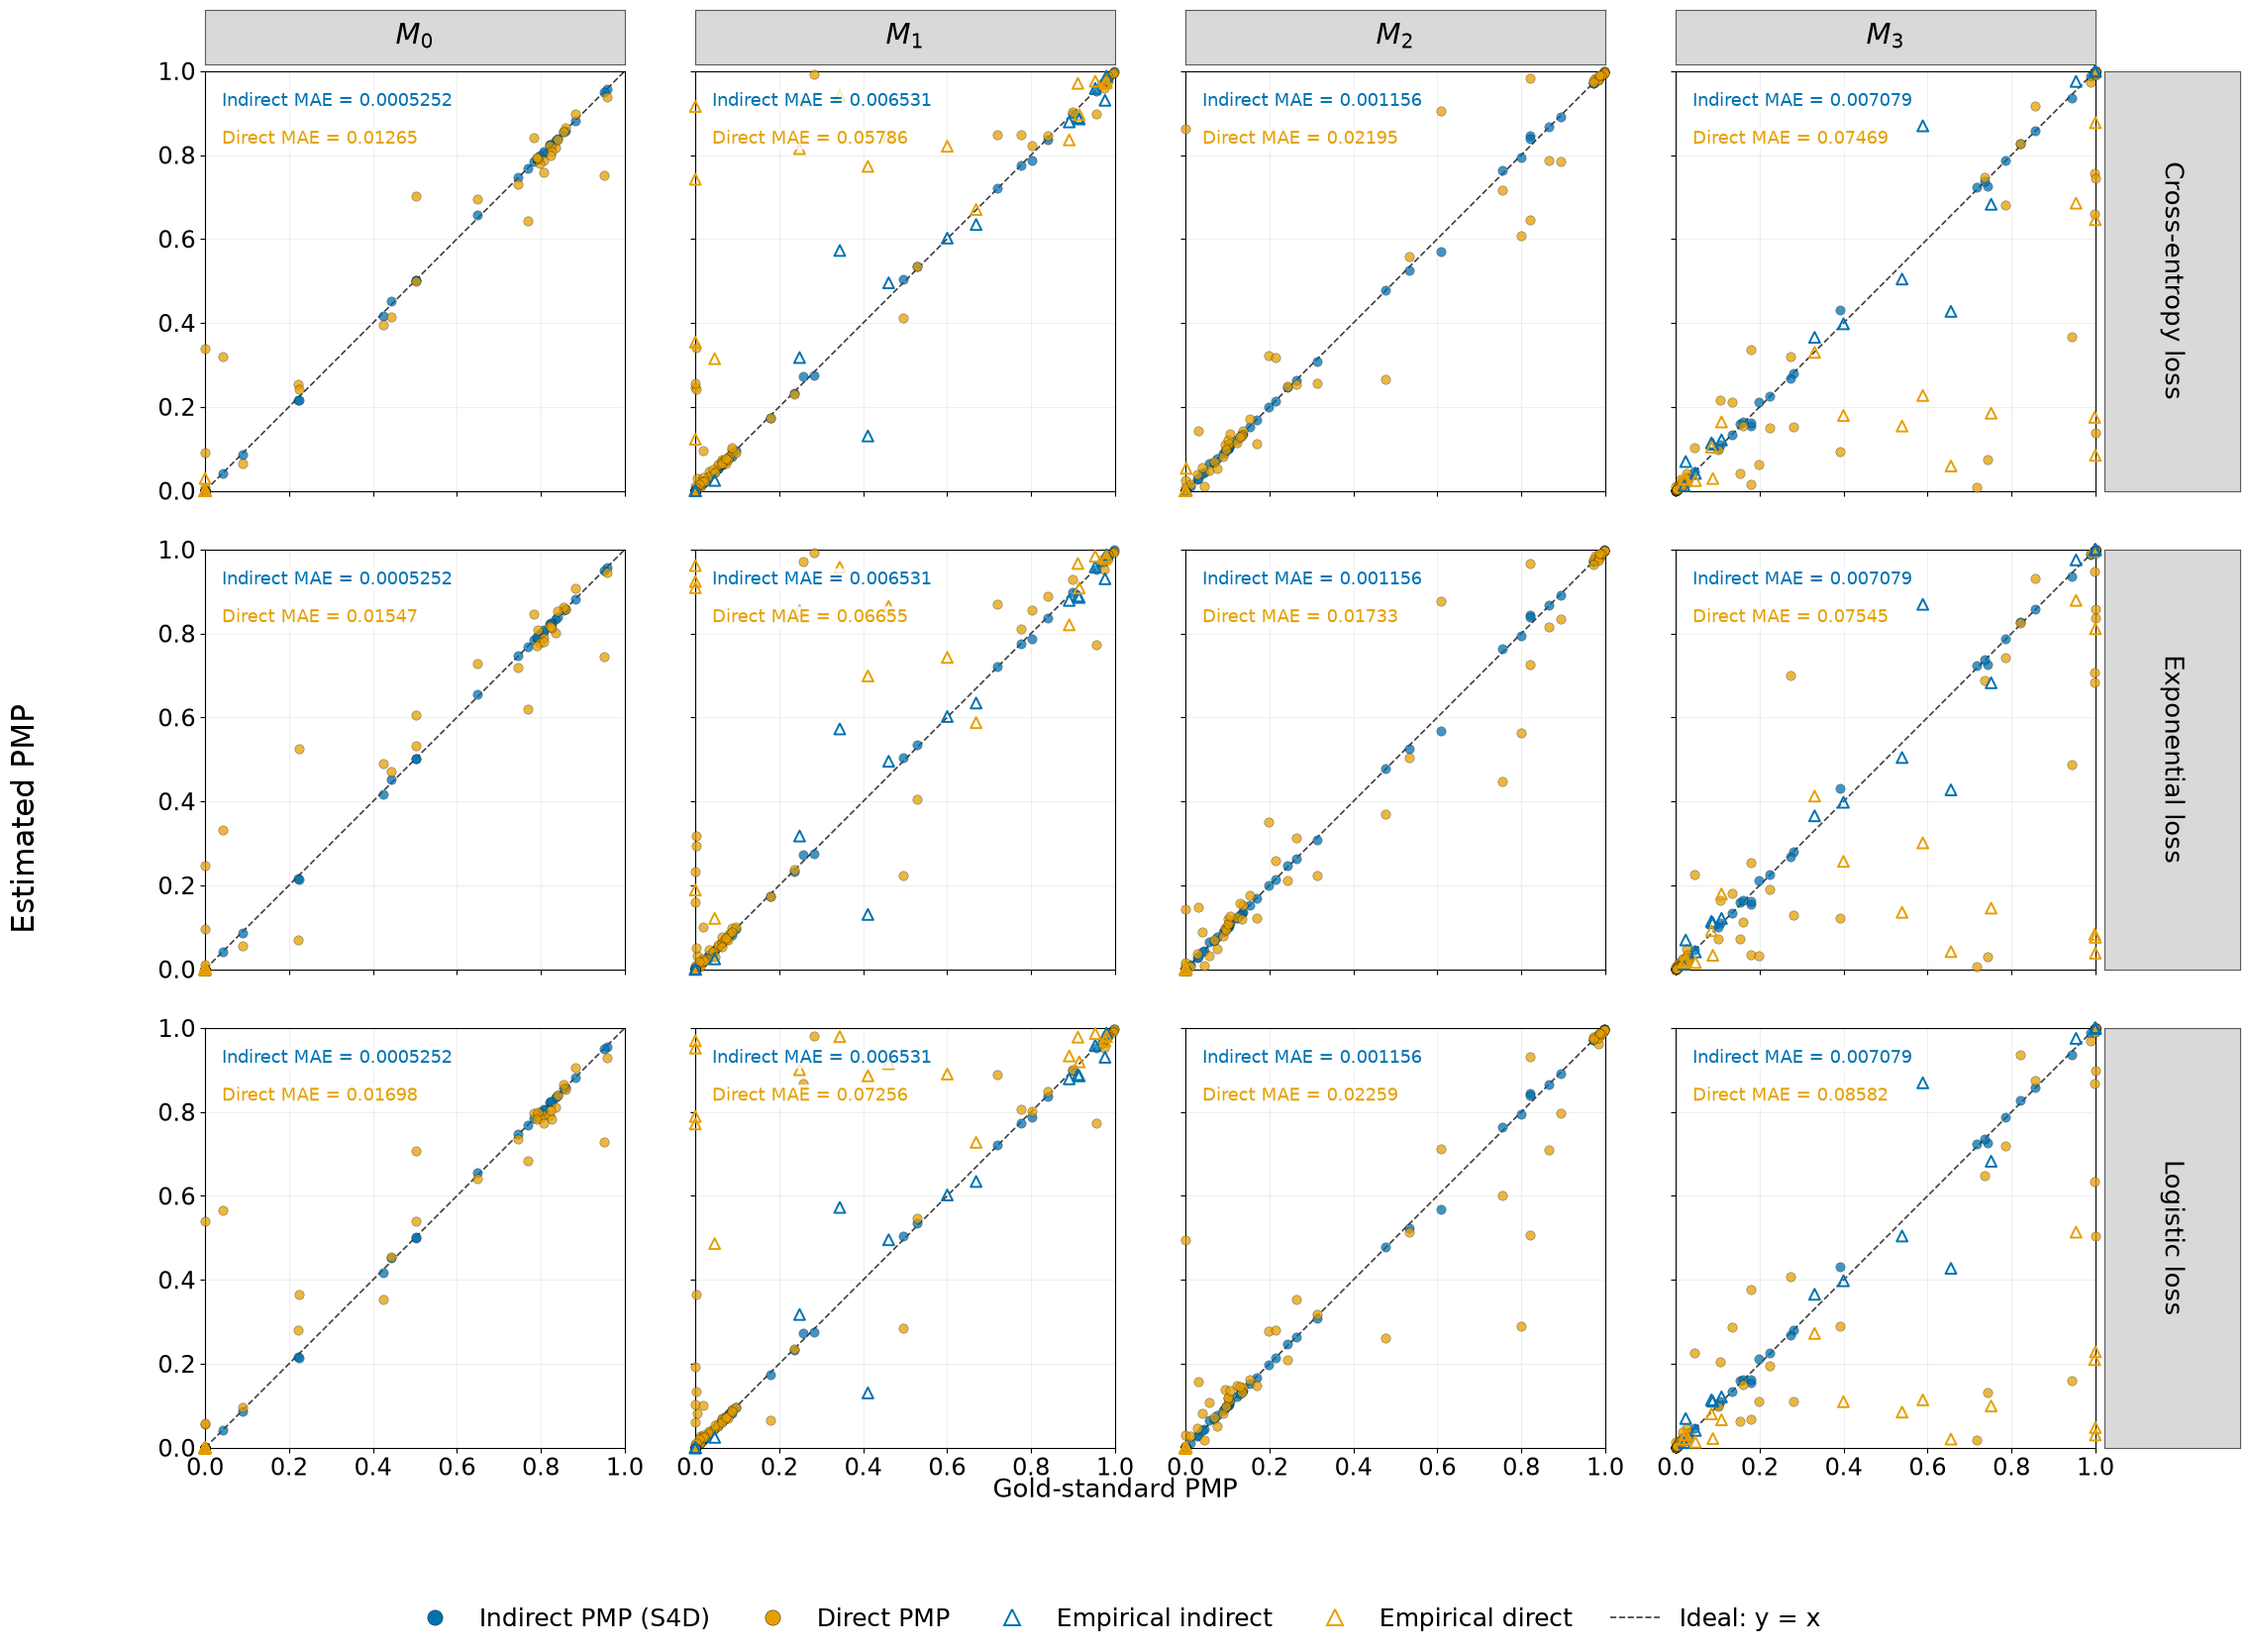

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/pmp_recovery_empirical_highlight_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/pmp_recovery_empirical_highlight_all.pdf


In [3]:
method_colors = {"indirect": "#0072B2", "direct": "#E69F00"}
has_empirical = "empirical" in selected_datasets

with plt.rc_context({"font.size": 17, "savefig.facecolor": "white"}):
    figure_height = 17.5
    fig, axes = plt.subplots(len(LOSS_FUNCTIONS), len(MODELS),
                             figsize=(23.5, figure_height), sharex=True,
                             sharey=True, squeeze=False)
    fig.subplots_adjust(left=0.105, right=0.925, bottom=2.4 / figure_height,
                        top=1.0 - 1.2 / figure_height, wspace=0.12, hspace=0.14)

    for loss, row_axes in zip(LOSS_FUNCTIONS, axes, strict=True):
        data = plot_data_by_loss[loss]
        empirical = data.index.get_level_values("dataset") == "empirical"
        for model, ax in zip(MODELS, row_axes, strict=True):
            gold = data[f"p_gold_{model}"].to_numpy(float)
            indirect = data[f"p_indirect_{model}"].to_numpy(float)
            direct = data[f"p_direct_{model}"].to_numpy(float)

            ax.set_axisbelow(True)
            ax.grid(alpha=0.2)
            ax.plot([0, 1], [0, 1], "--", color="0.25", linewidth=1.2, zorder=1)
            for method, estimate in (("indirect", indirect), ("direct", direct)):
                ax.scatter(gold[~empirical], estimate[~empirical], s=45, marker="o",
                           color=method_colors[method], alpha=0.75,
                           edgecolors="black", linewidths=0.25,
                           zorder=2 if method == "indirect" else 3,
                           clip_on=False)
                if has_empirical:
                    ax.scatter(gold[empirical], estimate[empirical], s=62,
                               marker="^", facecolors="none",
                               edgecolors=method_colors[method], linewidths=1.4,
                               zorder=4 if method == "indirect" else 5,
                               clip_on=False)
            for y, method, estimate in ((0.95, "indirect", indirect),
                                        (0.86, "direct", direct)):
                mae = np.mean(np.abs(estimate - gold))
                ax.text(0.04, y, f"{method.capitalize()} MAE = {mae:.4g}",
                        transform=ax.transAxes, ha="left", va="top",
                        color=method_colors[method], fontsize=13,
                        bbox={"facecolor": "white", "edgecolor": "none",
                              "alpha": 0.8, "pad": 1.4}, zorder=6)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_aspect("equal", adjustable="box")
            ax.tick_params(labelbottom=loss == LOSS_FUNCTIONS[-1],
                           labelleft=model == MODELS[0], labelsize=17)

    add_recovery_facet_strips(
        fig, axes,
        [rf"$M_{{{model[1:]}}}$" for model in MODELS],
        [f"{LOSS_LABELS[loss]} loss" for loss in LOSS_FUNCTIONS],
    )
    fig.supxlabel("Gold-standard PMP", y=0.105, fontsize=19)
    fig.supylabel("Estimated PMP", x=0.025, fontsize=22)
    legend_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=11,
               markerfacecolor=method_colors[method], markeredgecolor="black",
               markeredgewidth=0.3, label=label)
        for method, label in (("indirect", f"Indirect PMP ({INDIRECT_LABEL})"),
                              ("direct", "Direct PMP"))
    ]
    if has_empirical:
        legend_handles.extend(
            Line2D([], [], linestyle="none", marker="^", markersize=11,
                   markerfacecolor="none", markeredgecolor=method_colors[method],
                   markeredgewidth=1.4, label=f"Empirical {method}")
            for method in ("indirect", "direct")
        )
    legend_handles.append(Line2D([], [], linestyle="--", color="0.25",
                                 linewidth=1.2, label="Ideal: y = x"))
    fig.legend(handles=legend_handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.3125 / figure_height),
               ncol=len(legend_handles), frameon=False, fontsize=18,
               columnspacing=1.5)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    recovery_stem = "pmp_recovery_empirical_highlight" if has_empirical else "pmp_recovery"
    png_path = FIGURE_DIR / f"{recovery_stem}_{figure_suffix}.png"
    pdf_path = FIGURE_DIR / f"{recovery_stem}_{figure_suffix}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")


## Recovery by dataset source


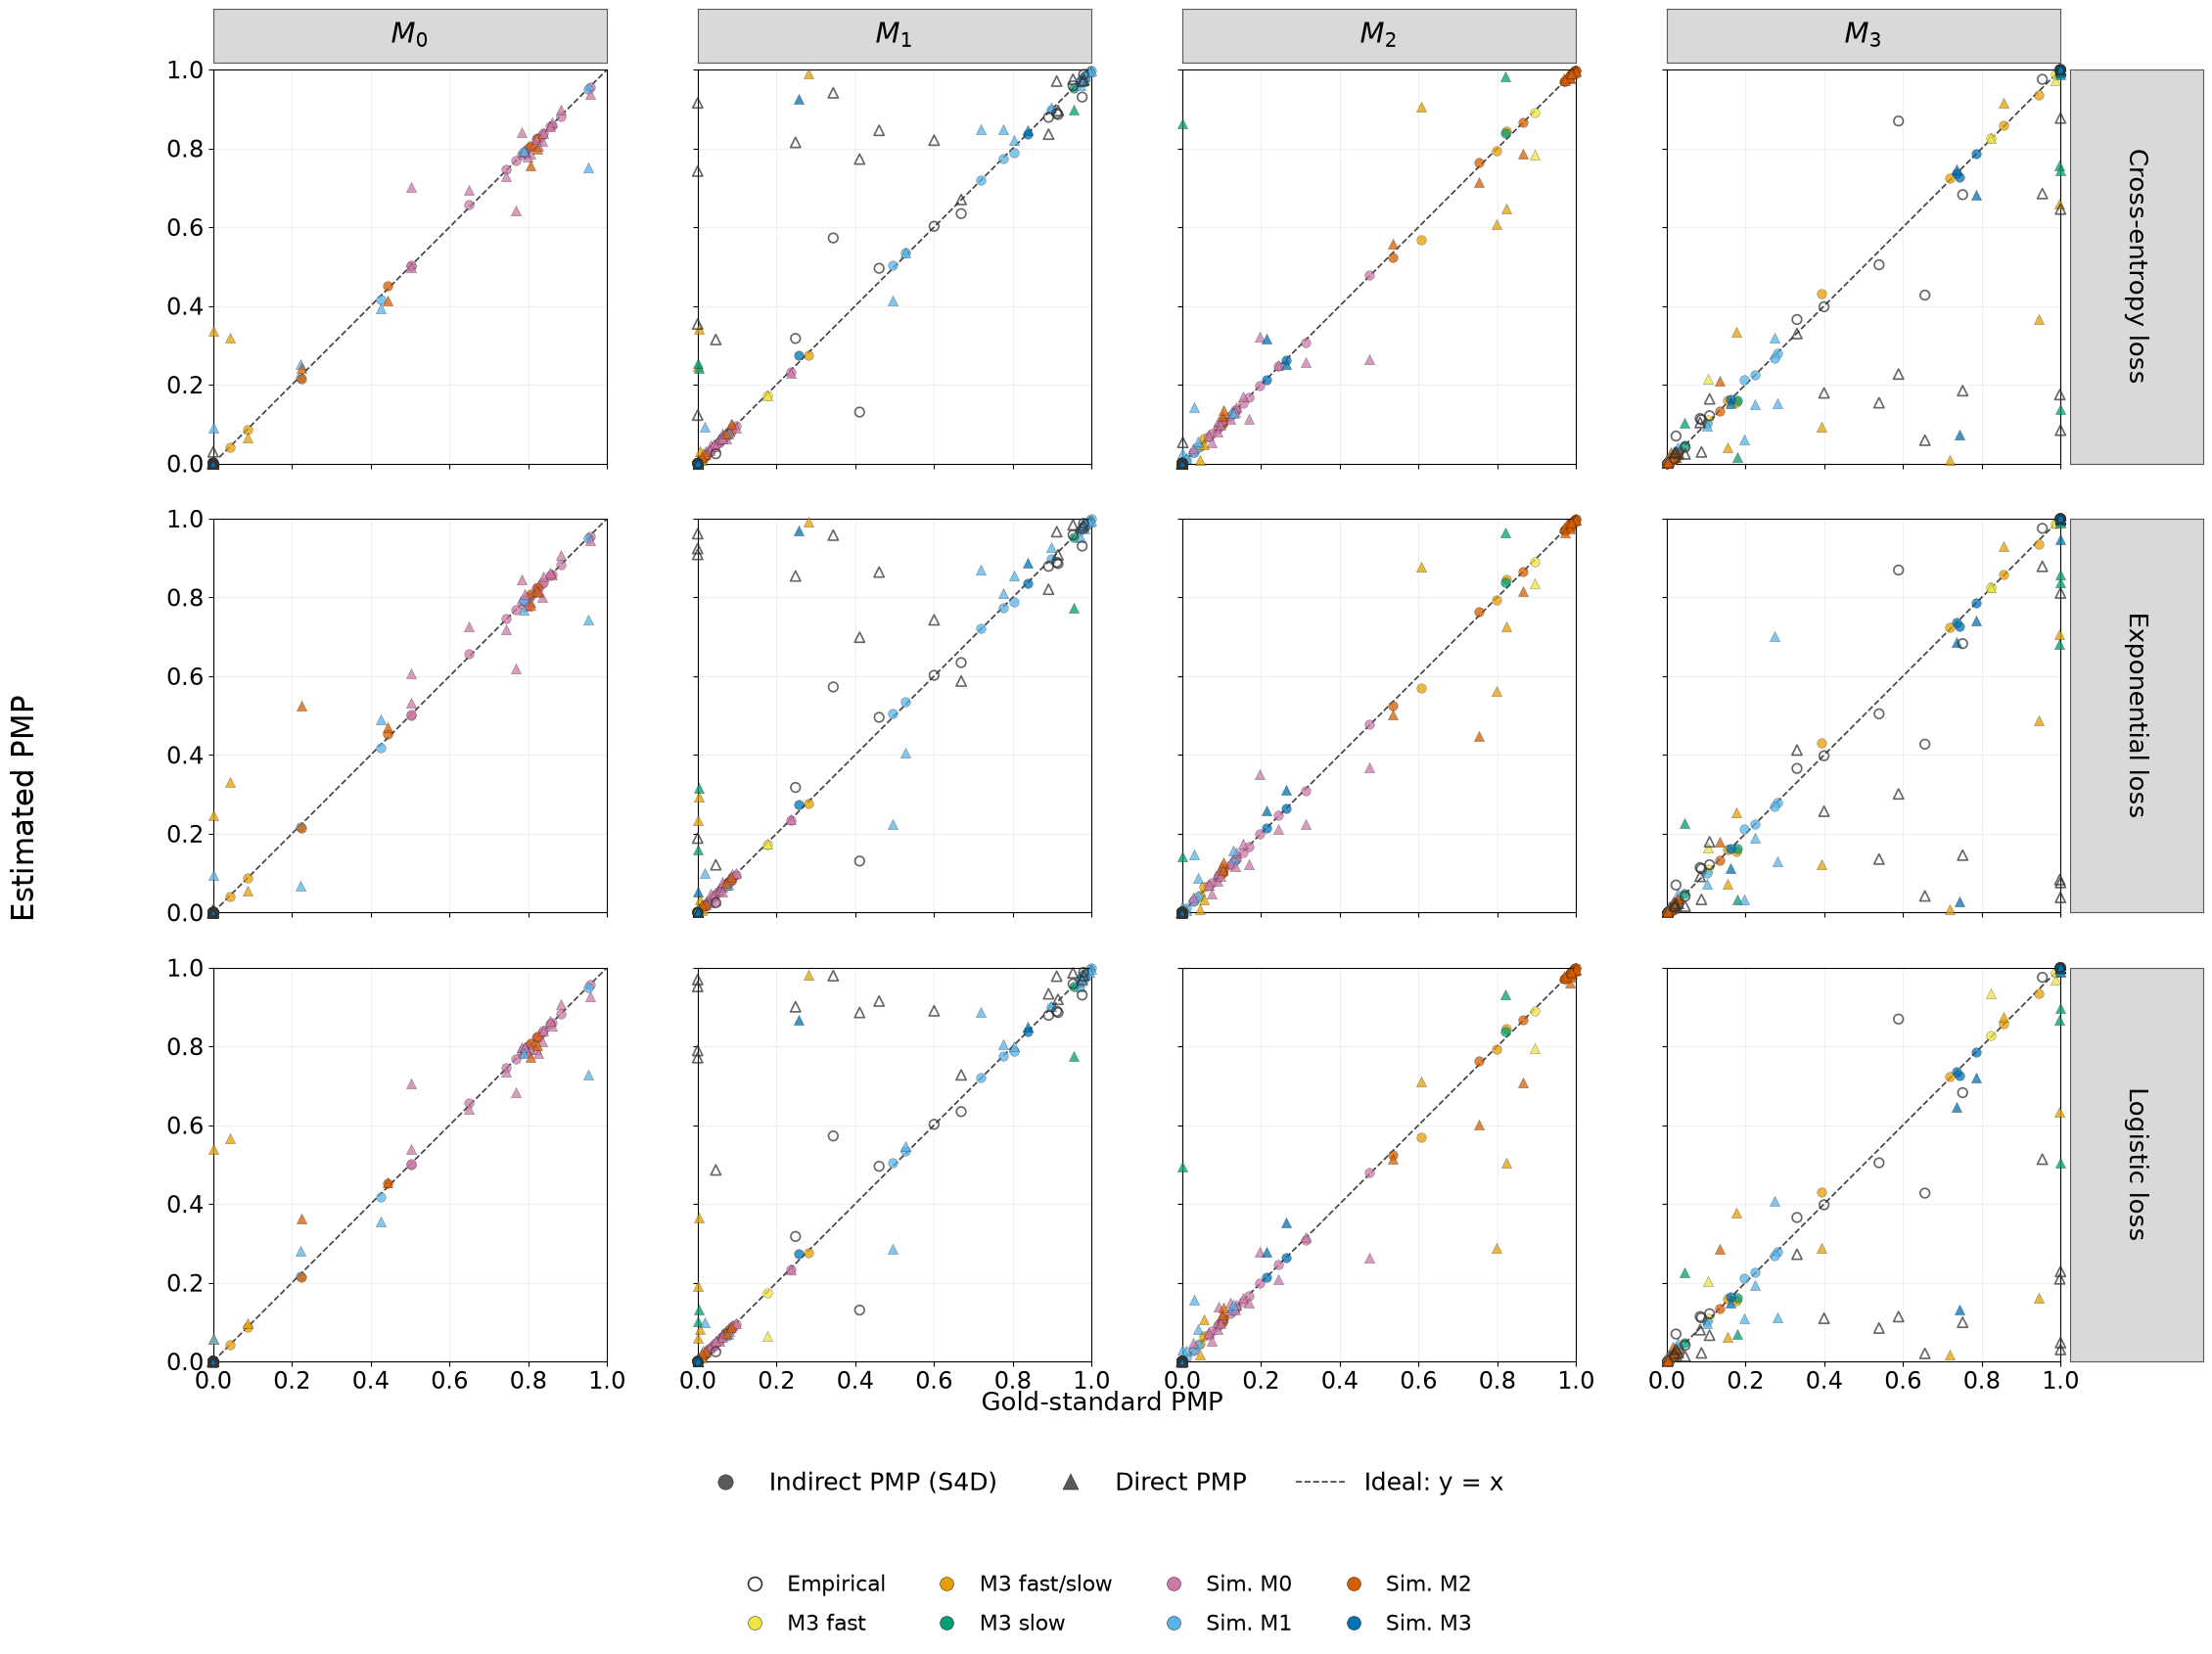

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/pmp_recovery_by_source_all_losses_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/pmp_recovery_by_source_all_losses_all.pdf


In [4]:
source_models = list(selected_datasets)
SOURCE_LABELS = {
    "empirical": "Empirical",
    "simulated_from_m0": "Sim. M0",
    "simulated_from_m1": "Sim. M1",
    "simulated_from_m2": "Sim. M2",
    "simulated_from_m3": "Sim. M3",
    "m3_fast_30": "M3 fast",
    "m3_slow_30": "M3 slow",
    "m3_fast_slow_30": "M3 fast/slow",
}
source_palette = (
    "#F0E442", "#E69F00", "#009E73", "#CC79A7",
    "#56B4E9", "#D55E00", "#0072B2", "#E011CF",
)
if len(source_models) > len(source_palette):
    raise ValueError("Not enough source colors")
simulated_sources = [source for source in source_models if source != "empirical"]
source_colors = dict(zip(simulated_sources, source_palette, strict=False))
if "empirical" in source_models:
    source_colors["empirical"] = "#333333"
method_markers = {"indirect": "o", "direct": "^"}

with plt.rc_context({"font.size": 17, "savefig.facecolor": "white"}):
    figure_height = 17.5
    fig, axes = plt.subplots(len(LOSS_FUNCTIONS), len(MODELS),
                             figsize=(23.5, figure_height), sharex=True,
                             sharey=True, squeeze=False)
    fig.subplots_adjust(left=0.105, right=0.925, bottom=3.1 / figure_height,
                        top=1.0 - 1.2 / figure_height, wspace=0.12, hspace=0.14)

    for loss, row_axes in zip(LOSS_FUNCTIONS, axes, strict=True):
        plot_data = plot_data_by_loss[loss]
        for model, ax in zip(MODELS, row_axes, strict=True):
            ax.set_axisbelow(True)
            ax.grid(alpha=0.2)
            ax.plot([0, 1], [0, 1], "--", color="0.25", linewidth=1.2, zorder=1)
            for source in source_models:
                sub = plot_data.xs(source, level="dataset", drop_level=False)
                gold = sub[f"p_gold_{model}"].to_numpy(float)
                for method, estimate in (
                    ("indirect", sub[f"p_indirect_{model}"].to_numpy(float)),
                    ("direct", sub[f"p_direct_{model}"].to_numpy(float)),
                ):
                    empirical = source == "empirical"
                    ax.scatter(gold, estimate,
                               s=48 if method == "indirect" else 55,
                               marker=method_markers[method],
                               facecolors="none" if empirical else source_colors[source],
                               edgecolors=source_colors[source] if empirical else "black",
                               alpha=0.75, linewidths=1.2 if empirical else 0.2,
                               zorder=4 if empirical else 2 if method == "indirect" else 3,
                               clip_on=False)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_aspect("equal", adjustable="box")
            ax.tick_params(labelbottom=loss == LOSS_FUNCTIONS[-1],
                           labelleft=model == MODELS[0], labelsize=17)

    add_recovery_facet_strips(
        fig, axes,
        [rf"$M_{{{model[1:]}}}$" for model in MODELS],
        [f"{LOSS_LABELS[loss]} loss" for loss in LOSS_FUNCTIONS],
    )
    fig.supxlabel("Gold-standard PMP", y=0.145, fontsize=19)
    fig.supylabel("Estimated PMP", x=0.025, fontsize=22)
    method_handles = [
        Line2D([], [], linestyle="none", marker=method_markers[method],
               markersize=11, markerfacecolor="0.35", markeredgecolor="black",
               markeredgewidth=0.3, label=label)
        for method, label in (("indirect", f"Indirect PMP ({INDIRECT_LABEL})"),
                              ("direct", "Direct PMP"))
    ]
    method_handles.append(Line2D([], [], linestyle="--", color="0.25",
                                 linewidth=1.2, label="Ideal: y = x"))
    source_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=10,
               markerfacecolor="none" if source == "empirical" else source_colors[source],
               markeredgecolor=source_colors[source] if source == "empirical" else "black",
               markeredgewidth=1.2 if source == "empirical" else 0.3,
               label=SOURCE_LABELS.get(source, source))
        for source in source_models
    ]
    fig.legend(handles=method_handles, loc="lower center",
               bbox_to_anchor=(0.5, 1.5 / figure_height), ncol=3,
               frameon=False, fontsize=18, columnspacing=2.0)
    fig.legend(handles=source_handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.1 / figure_height),
               ncol=min(4, len(source_models)), frameon=False, fontsize=16,
               columnspacing=1.8, handletextpad=0.5, labelspacing=0.8)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    png_path = FIGURE_DIR / f"pmp_recovery_by_source_all_losses_{figure_suffix}.png"
    pdf_path = FIGURE_DIR / f"pmp_recovery_by_source_all_losses_{figure_suffix}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")


In [5]:
import importlib
from benchmark.examples import direct_detection

importlib.reload(direct_detection)
evaluate_direct_detection = direct_detection.evaluate_direct_detection
plot_direct_scores = direct_detection.plot_direct_scores

LOSS_COLORS = {"cent": "#0072B2", "exponential": "#E69F00", "logistic": "#CC79A7"}
diagnostic_data_by_loss = {}
detection_metrics = []
for loss in LOSS_FUNCTIONS:
    diagnostic_dir = RESULTS_DIR / f"direct_{LOSS_KEYS[loss]}" / "diagnostics"
    diagnostic_path = diagnostic_dir / "diagnostic_frame.csv"
    diagnostic_metadata = json.loads((diagnostic_dir / "metadata.json").read_text())
    diagnostics = pd.read_csv(diagnostic_path, dtype={"dataset": str, "id": str})
    calibration_path = RESULTS_DIR / f"direct_{LOSS_KEYS[loss]}" / "calibration" / "thresholds.csv"
    calibration_metadata = json.loads((calibration_path.parent / "metadata.json").read_text())
    if (diagnostic_metadata["output_sha256"]["diagnostics/diagnostic_frame.csv"] != file_sha256(diagnostic_path)
        or calibration_metadata["output_sha256"]["thresholds"] != file_sha256(calibration_path)):
        raise ValueError(f"Stale direct diagnostics or PMP calibration for {loss}")
    diagnostic_data_by_loss[loss], metrics = evaluate_direct_detection(
        diagnostics,
        comparison_by_loss[loss],
        pd.read_csv(calibration_path),
        keys=("dataset", "id"),
        loss=LOSS_KEYS[loss],
    )
    detection_metrics.append(metrics)
detection_metrics = pd.concat(detection_metrics, ignore_index=True)
detection_metrics["plot_loss"] = detection_metrics["loss_function"].map(
    {value: key for key, value in LOSS_KEYS.items()}
)
metrics_path = RESULTS_DIR / "direct_loss_comparison" / "diagnostic_detection_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
detection_metrics.to_csv(metrics_path, index=False)
display(detection_metrics)

,loss_function,diagnostic,n_datasets,n_high_error,pmp_error_coverage,pmp_error_lower_threshold_m0,pmp_error_upper_threshold_m0,pmp_error_lower_threshold_m1,pmp_error_upper_threshold_m1,pmp_error_lower_threshold_m2,...,pmp_error_upper_threshold_m3,diagnostic_rho_threshold,TP,FP,TN,FN,FNR,FPR,ROC_AUC,plot_loss
0,cross_entropy,l2,136,45,0.9,-0.027984,0.037654,-0.024429,0.022502,-0.026803,...,0.013368,1.0,3,10,81,42,0.933333,0.109890,0.471062,cent
1,cross_entropy,linf,136,45,0.9,-0.027984,0.037654,-0.024429,0.022502,-0.026803,...,0.013368,1.0,4,8,83,41,0.911111,0.087912,0.435897,cent
2,cross_entropy,density,136,45,0.9,-0.027984,0.037654,-0.024429,0.022502,-0.026803,...,0.013368,1.0,19,27,64,26,0.577778,0.296703,0.595360,cent
3,cross_entropy,mmd,136,45,0.9,-0.027984,0.037654,-0.024429,0.022502,-0.026803,...,0.013368,1.0,0,9,82,45,1.000000,0.098901,0.278877,cent
4,exponential,l2,136,47,0.9,-0.030730,0.040716,-0.025800,0.028514,-0.033176,...,0.017647,1.0,1,7,82,46,0.978723,0.078652,0.482429,exponential
5,exponential,linf,136,47,0.9,-0.030730,0.040716,-0.025800,0.028514,-0.033176,...,0.017647,1.0,2,6,83,45,0.957447,0.067416,0.504901,exponential
6,exponential,density,136,47,0.9,-0.030730,0.040716,-0.025800,0.028514,-0.033176,...,0.017647,1.0,24,28,61,23,0.489362,0.314607,0.600048,exponential
7,exponential,mmd,136,47,0.9,-0.030730,0.040716,-0.025800,0.028514,-0.033176,...,0.017647,1.0,0,8,81,47,1.000000,0.089888,0.285441,exponential
8,logistic,l2,136,46,0.9,-0.045112,0.033712,-0.019696,0.033888,-0.033586,...,0.017993,1.0,8,4,86,38,0.826087,0.044444,0.494686,logistic
9,logistic,linf,136,46,0.9,-0.045112,0.033712,-0.019696,0.033888,-0.033586,...,0.017993,1.0,7,8,82,39,0.847826,0.088889,0.513285,logistic


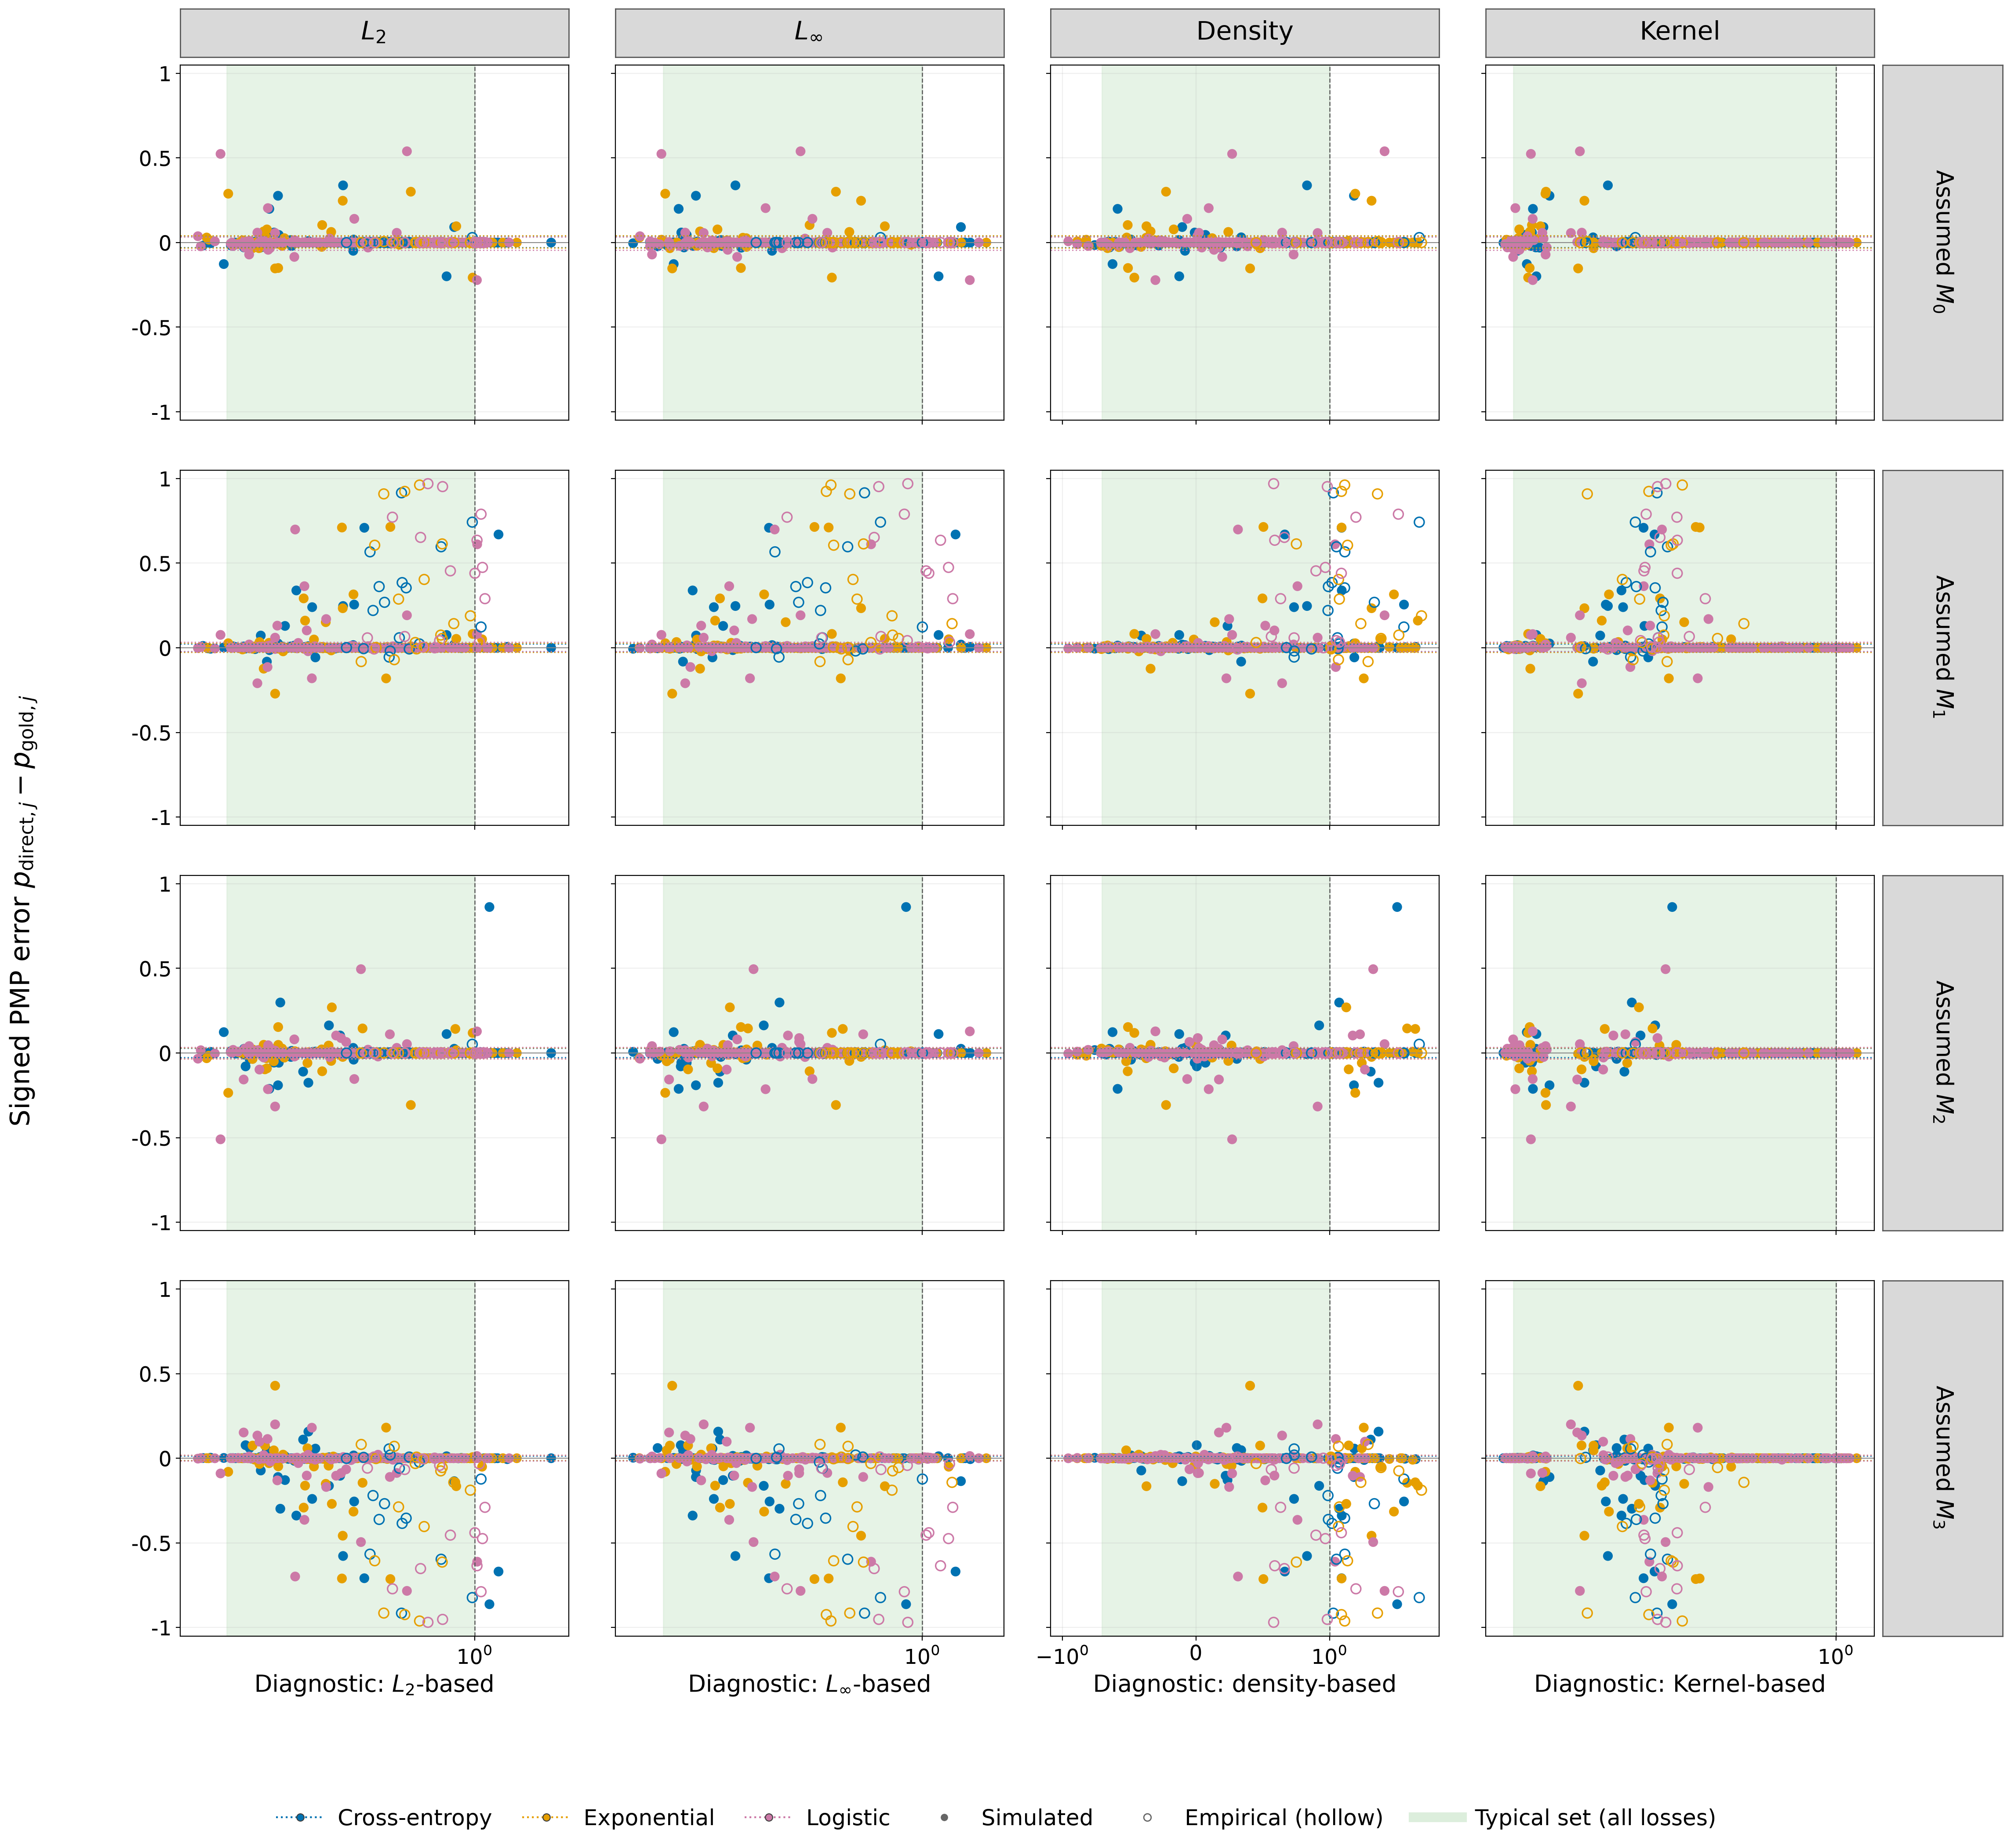

Saved diagnostic detection metrics to /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/diagnostic_detection_metrics.csv


In [6]:
from IPython.display import Image, display

selected_by_loss = {
    loss: data.loc[data["dataset"].isin(selected_datasets)]
    for loss, data in diagnostic_data_by_loss.items()
}
output_stem = FIGURE_DIR / f"direct_signed_pmp_error_all_losses_by_diagnostic_{figure_suffix}"
plot_direct_scores(
    selected_by_loss,
    loss_labels=LOSS_LABELS,
    loss_colors=LOSS_COLORS,
    empirical_dataset="empirical" if "empirical" in selected_datasets else None,
    output_stem=output_stem,
    facet_style=True,
    reference_style=True,
    point_size=64,
    point_alpha=1.0,
)
display(Image(filename=str(output_stem.with_suffix(".png"))))
print(f"Saved diagnostic detection metrics to {metrics_path}")


## Signed direct PMP error by dataset source and loss function


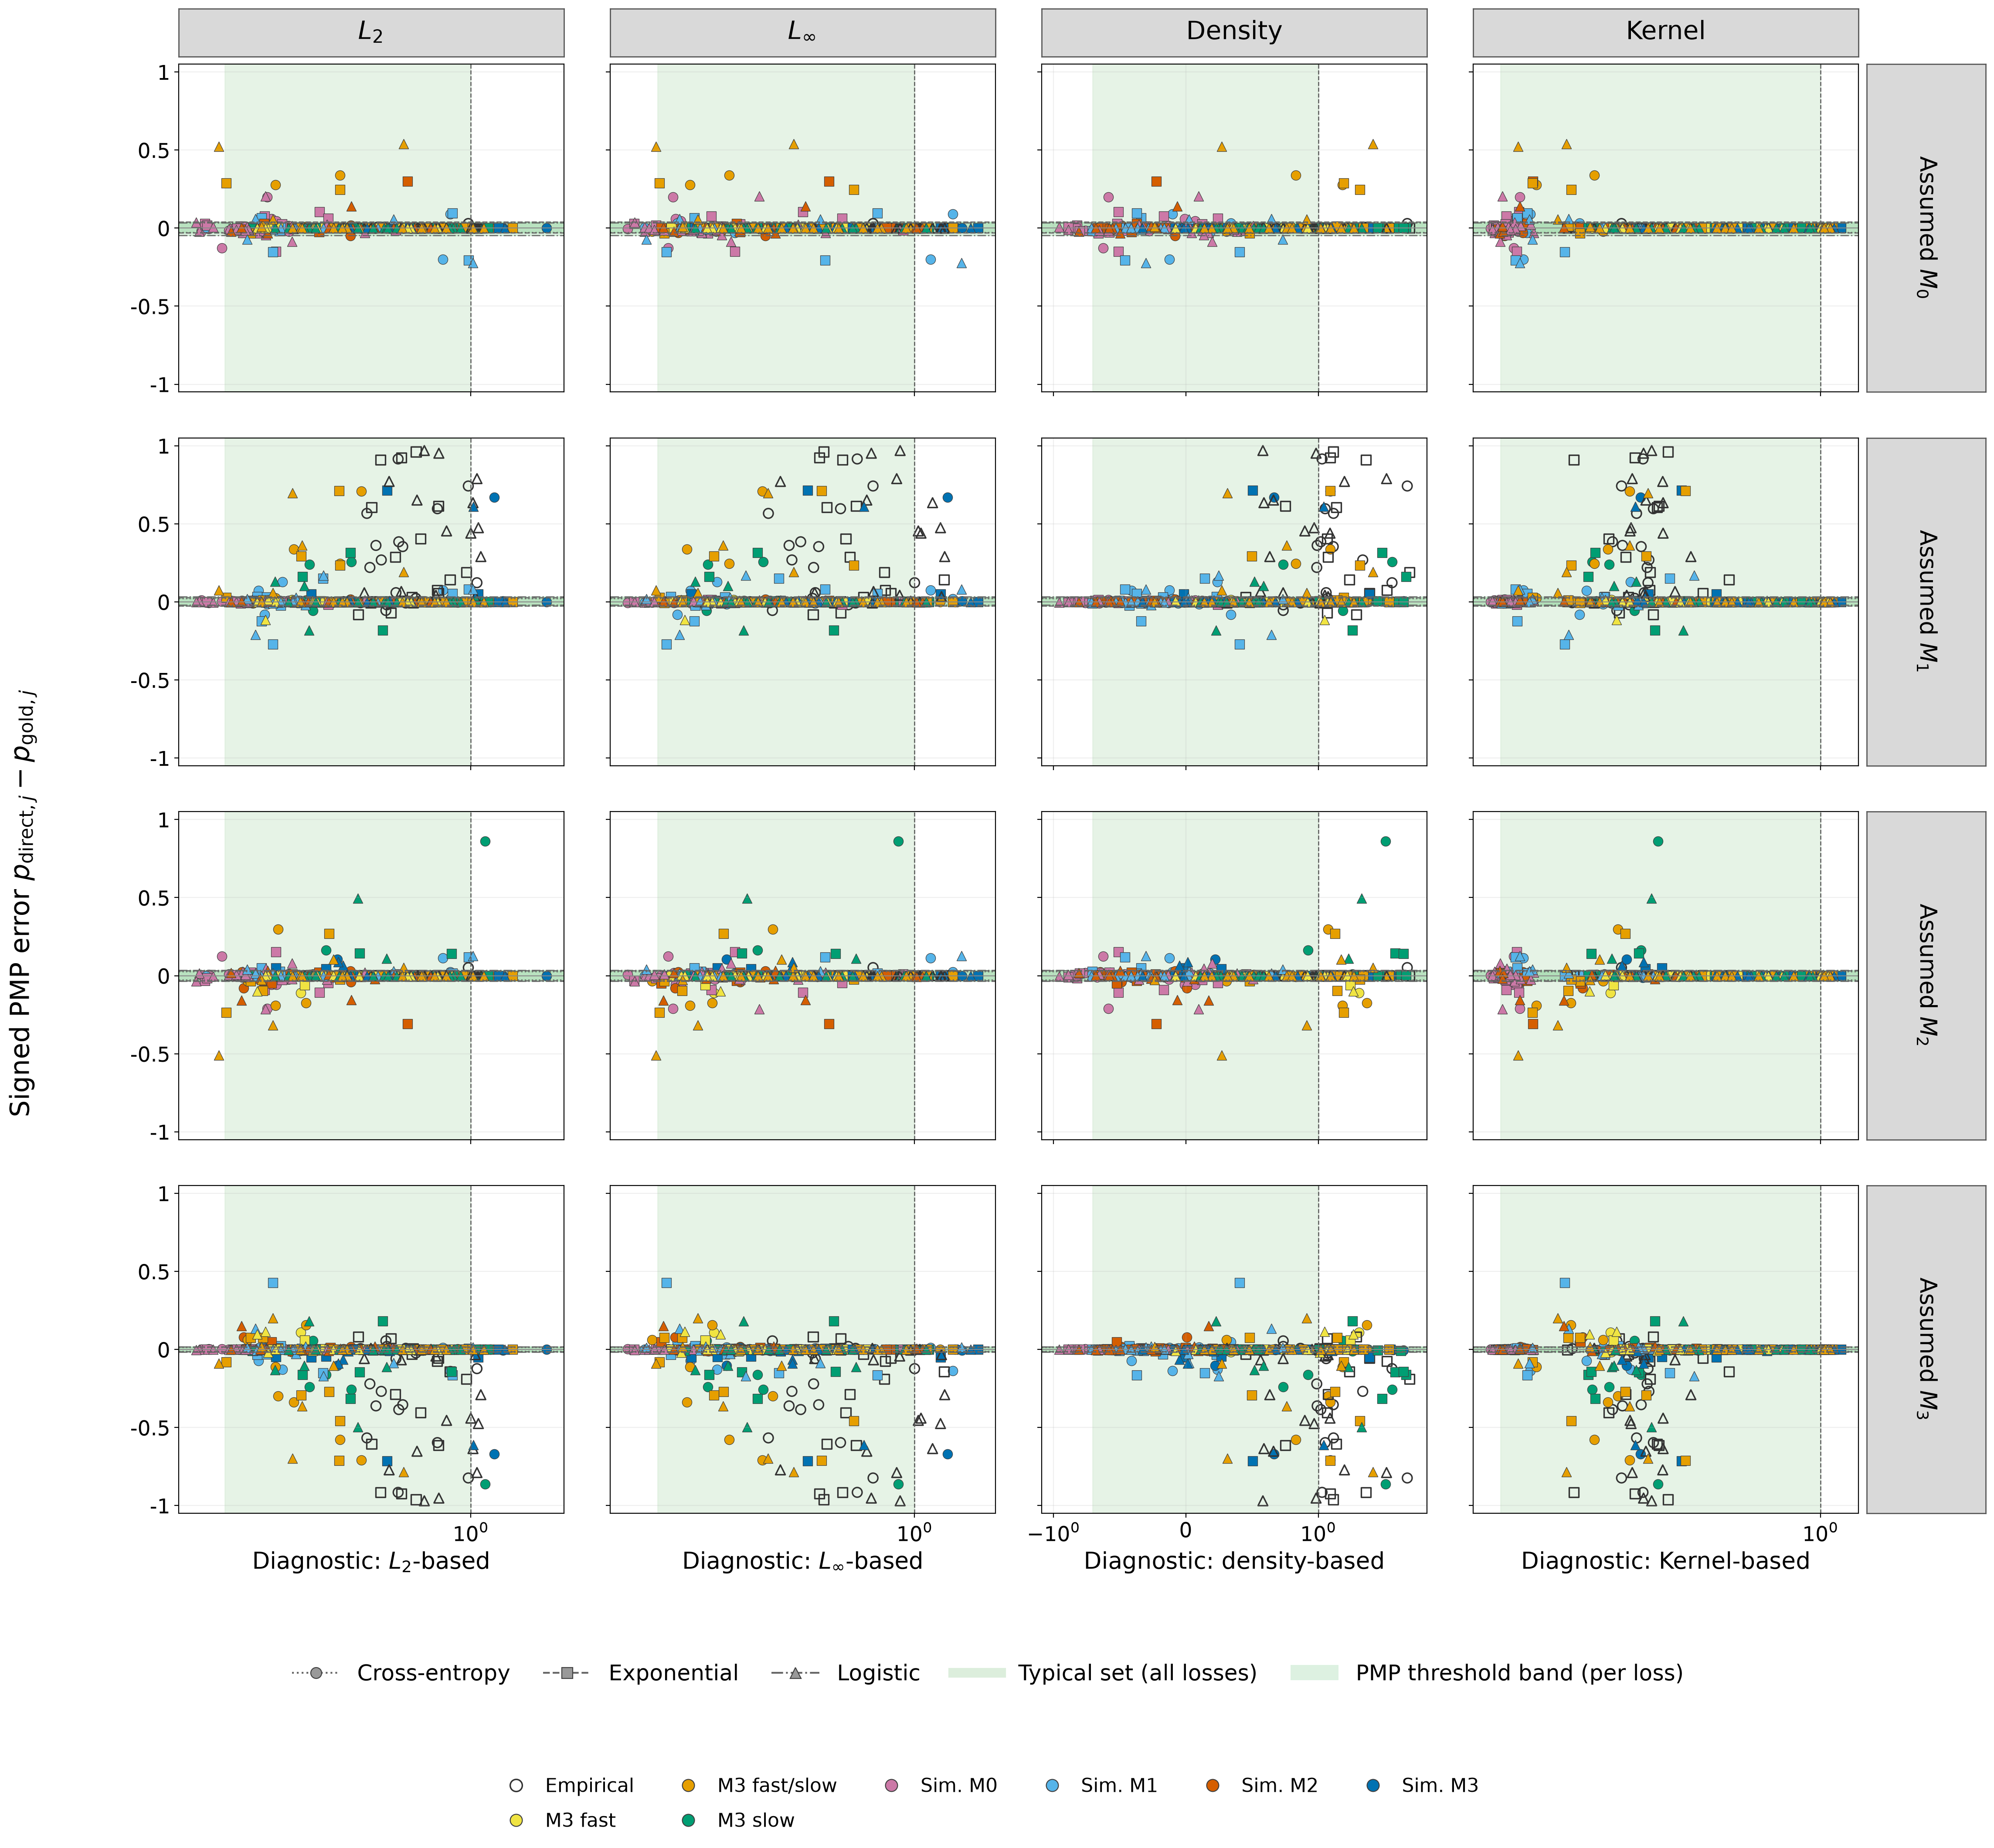

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/direct_signed_pmp_error_by_source_and_loss_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_loss_comparison/figures/direct_signed_pmp_error_by_source_and_loss_all.pdf


In [7]:
# Marker shape identifies the direct loss; point color identifies the dataset source.
LAST_PLOT_Y_SCALE = "linear"  # Change to "symlog" if needed.
LAST_PLOT_Y_SYMLOG_LINTHRESH = 0.01
LAST_PLOT_Y_LIMITS = (-1.05, 1.05)
LOSS_MARKERS = {"cent": "o", "exponential": "s", "logistic": "^"}
source_colors_for_plot = {source: source_colors[source] for source in source_models}
source_output_stem = FIGURE_DIR / f"direct_signed_pmp_error_by_source_and_loss_{figure_suffix}"
plot_direct_scores(
    selected_by_loss,
    loss_labels=LOSS_LABELS,
    loss_colors=LOSS_COLORS,
    empirical_dataset="empirical" if "empirical" in selected_datasets else None,
    output_stem=source_output_stem,
    facet_style=True,
    reference_style=True,
    point_size=64,
    point_alpha=1.0,
    source_colors=source_colors_for_plot,
    source_column="dataset",
    source_labels=SOURCE_LABELS,
    loss_markers=LOSS_MARKERS,
    y_scale=LAST_PLOT_Y_SCALE,
    y_symlog_linthresh=LAST_PLOT_Y_SYMLOG_LINTHRESH,
    y_limits=LAST_PLOT_Y_LIMITS,
    pmp_threshold_band=True,
)
display(Image(filename=str(source_output_stem.with_suffix(".png"))))
print(f"PNG: {source_output_stem.with_suffix('.png')}")
print(f"PDF: {source_output_stem.with_suffix('.pdf')}")
